# DNA Sequence Alignment: Needleman-Wunsch and Smith-Waterman Algorithms

This notebook explores the fundamental algorithms of bioinformatics for aligning biological sequences:
- **Needleman-Wunsch**: Global alignment (align entire sequences)
- **Smith-Waterman**: Local alignment (find best matching subsequences)

**Key Concepts:**
- Dynamic programming
- Scoring matrices (match, mismatch, gap penalties)
- Traceback for optimal alignment
- Biological applications (homology, mutations, evolution)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

## 1. Introduction to Sequence Alignment

Sequence alignment identifies regions of similarity between biological sequences (DNA, RNA, or proteins). These similarities often indicate:
- **Functional relationships**: Similar sequences may have similar functions
- **Evolutionary relationships**: Homologous sequences share common ancestry
- **Structural relationships**: Similar sequences may fold similarly

### Alignment Types

| Type | Algorithm | Use Case |
|------|-----------|----------|
| Global | Needleman-Wunsch | Align entire sequences of similar length |
| Local | Smith-Waterman | Find best matching regions within sequences |
| Semi-global | Modified NW | When one sequence should fit inside another |

## 2. Scoring System

Alignments are scored using:
- **Match score**: Reward for identical characters (+1 to +5 typically)
- **Mismatch penalty**: Cost for substitutions (-1 to -4 typically)
- **Gap penalty**: Cost for insertions/deletions (-2 to -10 typically)

The goal is to find the alignment with the **maximum score**.

In [2]:
# Define scoring parameters
MATCH = 2       # Score for matching characters
MISMATCH = -1   # Penalty for mismatching characters
GAP = -2        # Penalty for gaps (insertions/deletions)

def score(a, b):
    """Return the score for aligning characters a and b."""
    if a == b:
        return MATCH
    else:
        return MISMATCH

print("Scoring Parameters")
print("="*40)
print(f"Match:    +{MATCH}")
print(f"Mismatch: {MISMATCH}")
print(f"Gap:      {GAP}")
print()
print("Examples:")
print(f"  score('A', 'A') = {score('A', 'A')}")
print(f"  score('A', 'T') = {score('A', 'T')}")
print(f"  score('G', 'C') = {score('G', 'C')}")

Scoring Parameters
Match:    +2
Mismatch: -1
Gap:      -2

Examples:
  score('A', 'A') = 2
  score('A', 'T') = -1
  score('G', 'C') = -1


## 3. Needleman-Wunsch Algorithm (Global Alignment)

The Needleman-Wunsch algorithm finds the optimal **global alignment** between two sequences using dynamic programming.

### Recurrence Relation

For sequences $X$ (length $m$) and $Y$ (length $n$), we build a matrix $F$ where:

$$F(i,j) = \max \begin{cases}
F(i-1, j-1) + s(x_i, y_j) & \text{(match/mismatch)} \\
F(i-1, j) + g & \text{(gap in Y)} \\
F(i, j-1) + g & \text{(gap in X)}
\end{cases}$$

where $s(a,b)$ is the substitution score and $g$ is the gap penalty.

In [3]:
def needleman_wunsch(seq1, seq2, match=MATCH, mismatch=MISMATCH, gap=GAP):
    """
    Perform global alignment using Needleman-Wunsch algorithm.
    
    Returns:
    --------
    aligned1, aligned2 : str - Aligned sequences
    score_matrix : np.array - The dynamic programming matrix
    score : int - The alignment score
    """
    m, n = len(seq1), len(seq2)
    
    # Initialize score matrix
    F = np.zeros((m + 1, n + 1), dtype=int)
    
    # Initialize first row and column (gap penalties)
    for i in range(m + 1):
        F[i, 0] = i * gap
    for j in range(n + 1):
        F[0, j] = j * gap
    
    # Fill the matrix
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            match_score = match if seq1[i-1] == seq2[j-1] else mismatch
            F[i, j] = max(
                F[i-1, j-1] + match_score,  # Diagonal (match/mismatch)
                F[i-1, j] + gap,             # Up (gap in seq2)
                F[i, j-1] + gap              # Left (gap in seq1)
            )
    
    # Traceback to find alignment
    aligned1, aligned2 = '', ''
    i, j = m, n
    
    while i > 0 or j > 0:
        if i > 0 and j > 0:
            match_score = match if seq1[i-1] == seq2[j-1] else mismatch
            if F[i, j] == F[i-1, j-1] + match_score:
                aligned1 = seq1[i-1] + aligned1
                aligned2 = seq2[j-1] + aligned2
                i -= 1
                j -= 1
            elif i > 0 and F[i, j] == F[i-1, j] + gap:
                aligned1 = seq1[i-1] + aligned1
                aligned2 = '-' + aligned2
                i -= 1
            else:
                aligned1 = '-' + aligned1
                aligned2 = seq2[j-1] + aligned2
                j -= 1
        elif i > 0:
            aligned1 = seq1[i-1] + aligned1
            aligned2 = '-' + aligned2
            i -= 1
        else:
            aligned1 = '-' + aligned1
            aligned2 = seq2[j-1] + aligned2
            j -= 1
    
    return aligned1, aligned2, F, F[m, n]

# Example sequences
seq1 = "GCATGCG"
seq2 = "GATTACA"

aligned1, aligned2, score_matrix, alignment_score = needleman_wunsch(seq1, seq2)

print("Needleman-Wunsch Global Alignment")
print("="*50)
print(f"Sequence 1: {seq1}")
print(f"Sequence 2: {seq2}")
print()
print("Optimal Alignment:")
print(f"  {aligned1}")
print(f"  {''.join(['|' if a == b and a != '-' else ' ' for a, b in zip(aligned1, aligned2)])}")
print(f"  {aligned2}")
print(f"\nAlignment Score: {alignment_score}")

Needleman-Wunsch Global Alignment
Sequence 1: GCATGCG
Sequence 2: GATTACA

Optimal Alignment:
  GCATGCG
  |  | | 
  GATTACA

Alignment Score: 2


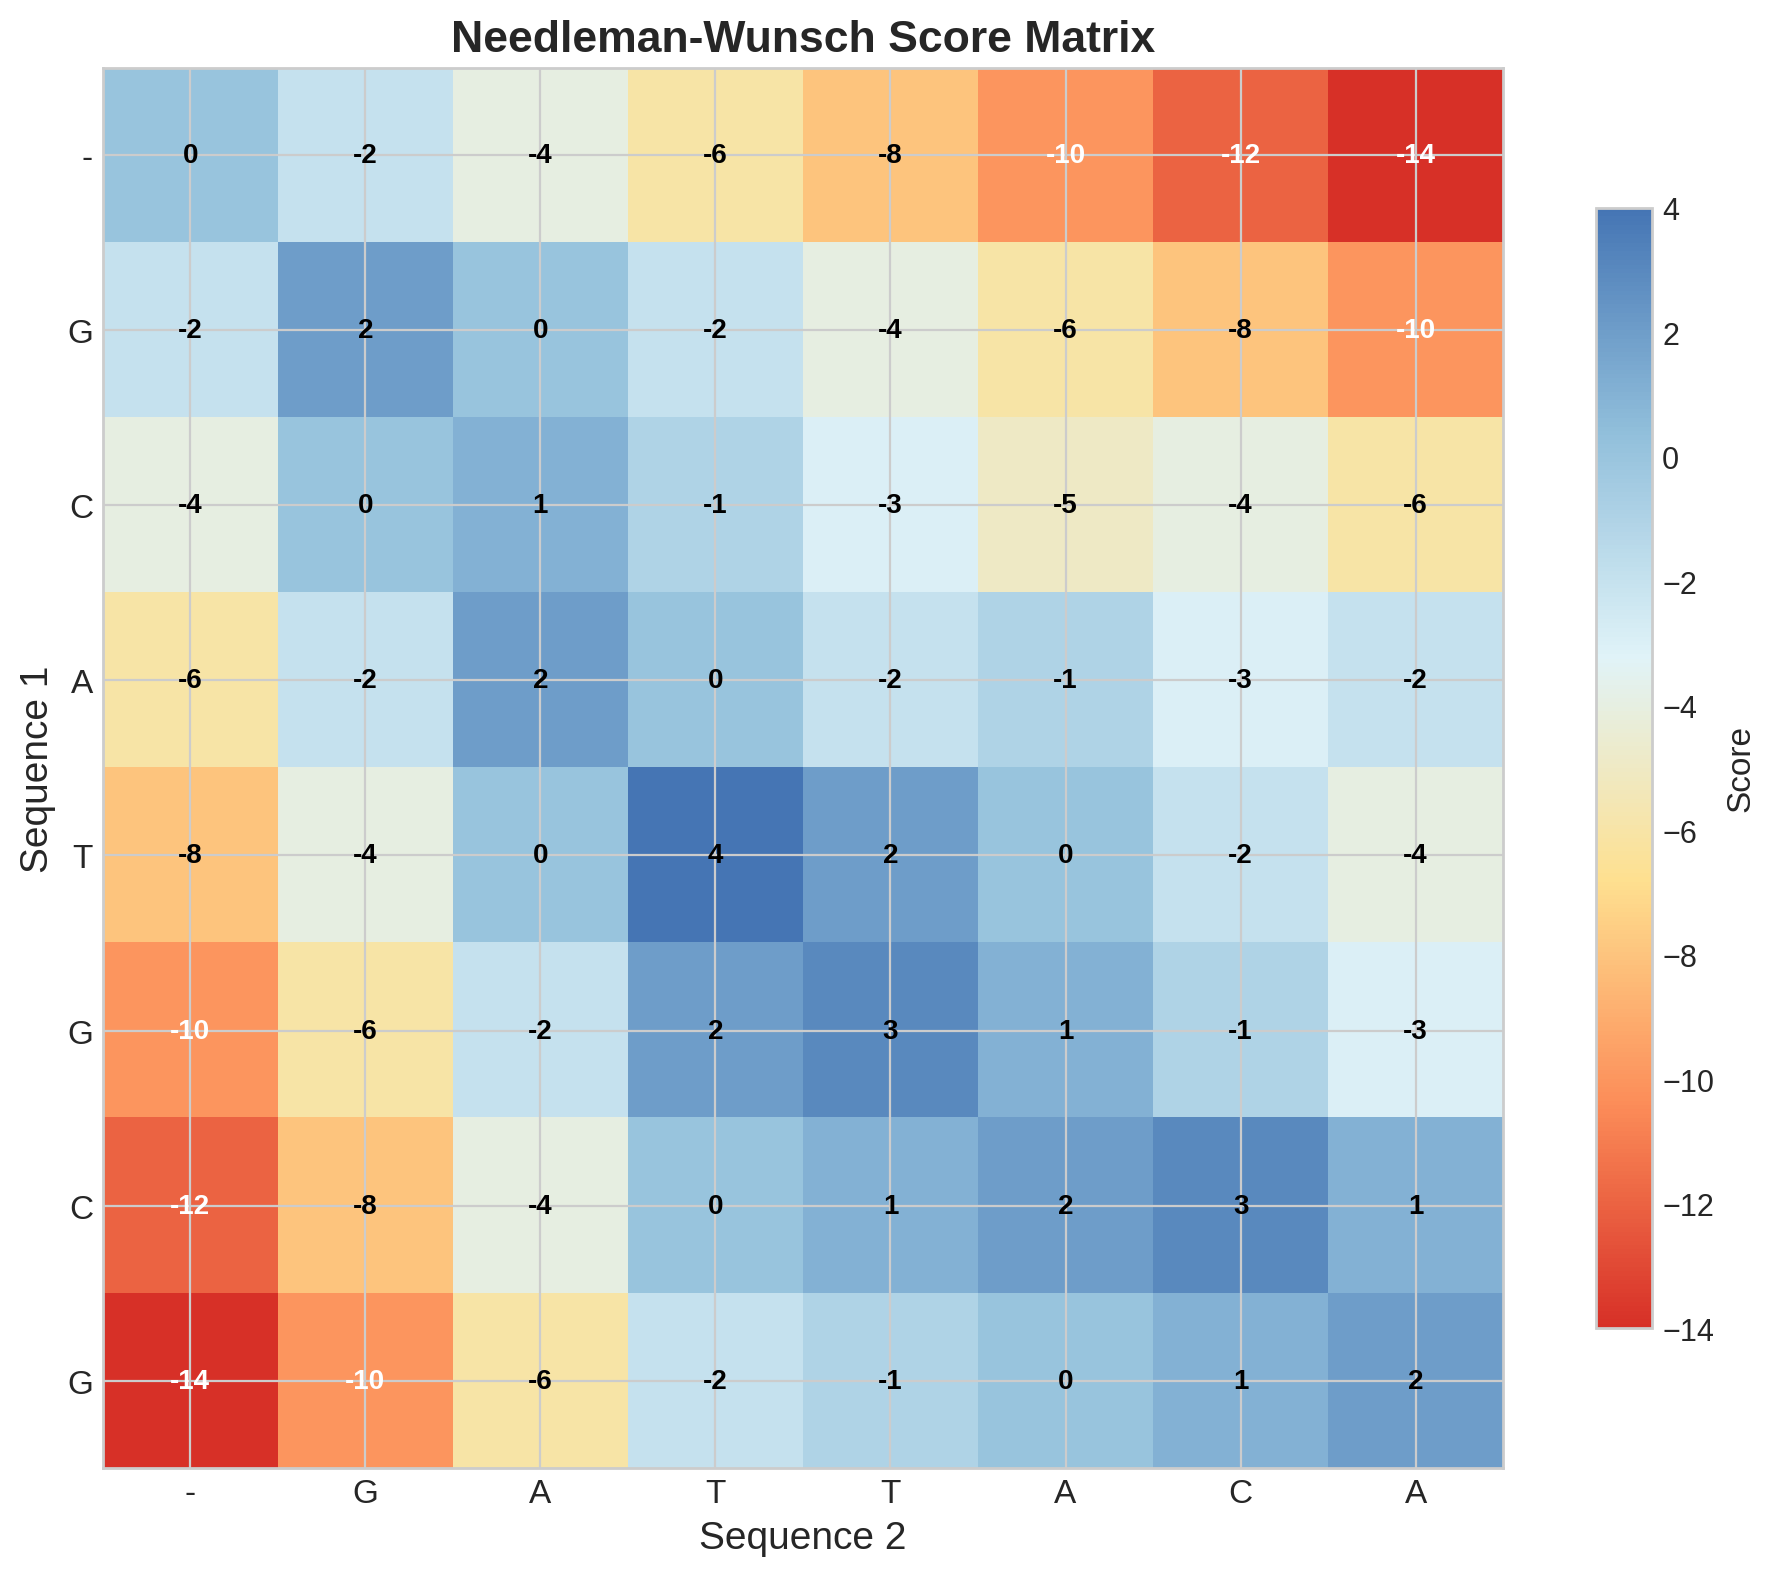

Plot saved: sequence_alignment_needleman_wunsch_matrix.png


In [4]:
# Visualize the scoring matrix
def visualize_alignment_matrix(seq1, seq2, matrix, title, algorithm='NW'):
    """
    Visualize the dynamic programming matrix.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create custom colormap
    colors = ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4']
    cmap = LinearSegmentedColormap.from_list('custom', colors)
    
    # Plot heatmap
    im = ax.imshow(matrix, cmap=cmap, aspect='equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Score', fontsize=12)
    
    # Add labels
    ax.set_xticks(range(len(seq2) + 1))
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=12)
    ax.set_yticklabels(['-'] + list(seq1), fontsize=12)
    
    # Add values in cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = int(matrix[i, j])
            color = 'white' if abs(value) > (matrix.max() - matrix.min()) / 2 else 'black'
            ax.text(j, i, value, ha='center', va='center', 
                   fontsize=10, fontweight='bold', color=color)
    
    ax.set_xlabel('Sequence 2', fontsize=14)
    ax.set_ylabel('Sequence 1', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    return fig

fig = visualize_alignment_matrix(seq1, seq2, score_matrix, 
                                  'Needleman-Wunsch Score Matrix')
plt.savefig('sequence_alignment_needleman_wunsch_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: sequence_alignment_needleman_wunsch_matrix.png")

## 4. Smith-Waterman Algorithm (Local Alignment)

The Smith-Waterman algorithm finds the optimal **local alignment** - the best matching subsequences within two sequences.

### Key Differences from Needleman-Wunsch

1. Negative scores are set to 0 (can start fresh anywhere)
2. Traceback starts from the **maximum score** in the matrix
3. Traceback ends when reaching a cell with score 0

$$F(i,j) = \max \begin{cases}
0 & \text{(reset)} \\
F(i-1, j-1) + s(x_i, y_j) & \text{(match/mismatch)} \\
F(i-1, j) + g & \text{(gap in Y)} \\
F(i, j-1) + g & \text{(gap in X)}
\end{cases}$$

In [5]:
def smith_waterman(seq1, seq2, match=MATCH, mismatch=MISMATCH, gap=GAP):
    """
    Perform local alignment using Smith-Waterman algorithm.
    
    Returns:
    --------
    aligned1, aligned2 : str - Aligned subsequences
    score_matrix : np.array - The dynamic programming matrix
    max_score : int - The alignment score
    start_pos : tuple - (i, j) position of max score
    """
    m, n = len(seq1), len(seq2)
    
    # Initialize score matrix (all zeros)
    F = np.zeros((m + 1, n + 1), dtype=int)
    
    # Track maximum score position
    max_score = 0
    max_pos = (0, 0)
    
    # Fill the matrix
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            match_score = match if seq1[i-1] == seq2[j-1] else mismatch
            F[i, j] = max(
                0,                           # Reset (key difference!)
                F[i-1, j-1] + match_score,   # Diagonal
                F[i-1, j] + gap,             # Up
                F[i, j-1] + gap              # Left
            )
            
            if F[i, j] > max_score:
                max_score = F[i, j]
                max_pos = (i, j)
    
    # Traceback from max score position
    aligned1, aligned2 = '', ''
    i, j = max_pos
    
    while i > 0 and j > 0 and F[i, j] > 0:
        match_score = match if seq1[i-1] == seq2[j-1] else mismatch
        
        if F[i, j] == F[i-1, j-1] + match_score:
            aligned1 = seq1[i-1] + aligned1
            aligned2 = seq2[j-1] + aligned2
            i -= 1
            j -= 1
        elif F[i, j] == F[i-1, j] + gap:
            aligned1 = seq1[i-1] + aligned1
            aligned2 = '-' + aligned2
            i -= 1
        else:
            aligned1 = '-' + aligned1
            aligned2 = seq2[j-1] + aligned2
            j -= 1
    
    return aligned1, aligned2, F, max_score, max_pos

# Longer sequences for local alignment example
seq1_local = "GGTTGACTA"
seq2_local = "TGTTACGG"

aligned1_sw, aligned2_sw, sw_matrix, sw_score, max_pos = smith_waterman(seq1_local, seq2_local)

print("Smith-Waterman Local Alignment")
print("="*50)
print(f"Sequence 1: {seq1_local}")
print(f"Sequence 2: {seq2_local}")
print()
print("Best Local Alignment:")
print(f"  {aligned1_sw}")
print(f"  {''.join(['|' if a == b and a != '-' else ' ' for a, b in zip(aligned1_sw, aligned2_sw)])}")
print(f"  {aligned2_sw}")
print(f"\nAlignment Score: {sw_score}")
print(f"Max Score Position: row {max_pos[0]}, col {max_pos[1]}")

Smith-Waterman Local Alignment
Sequence 1: GGTTGACTA
Sequence 2: TGTTACGG

Best Local Alignment:
  GTTGAC
  ||| ||
  GTT-AC

Alignment Score: 8
Max Score Position: row 7, col 6


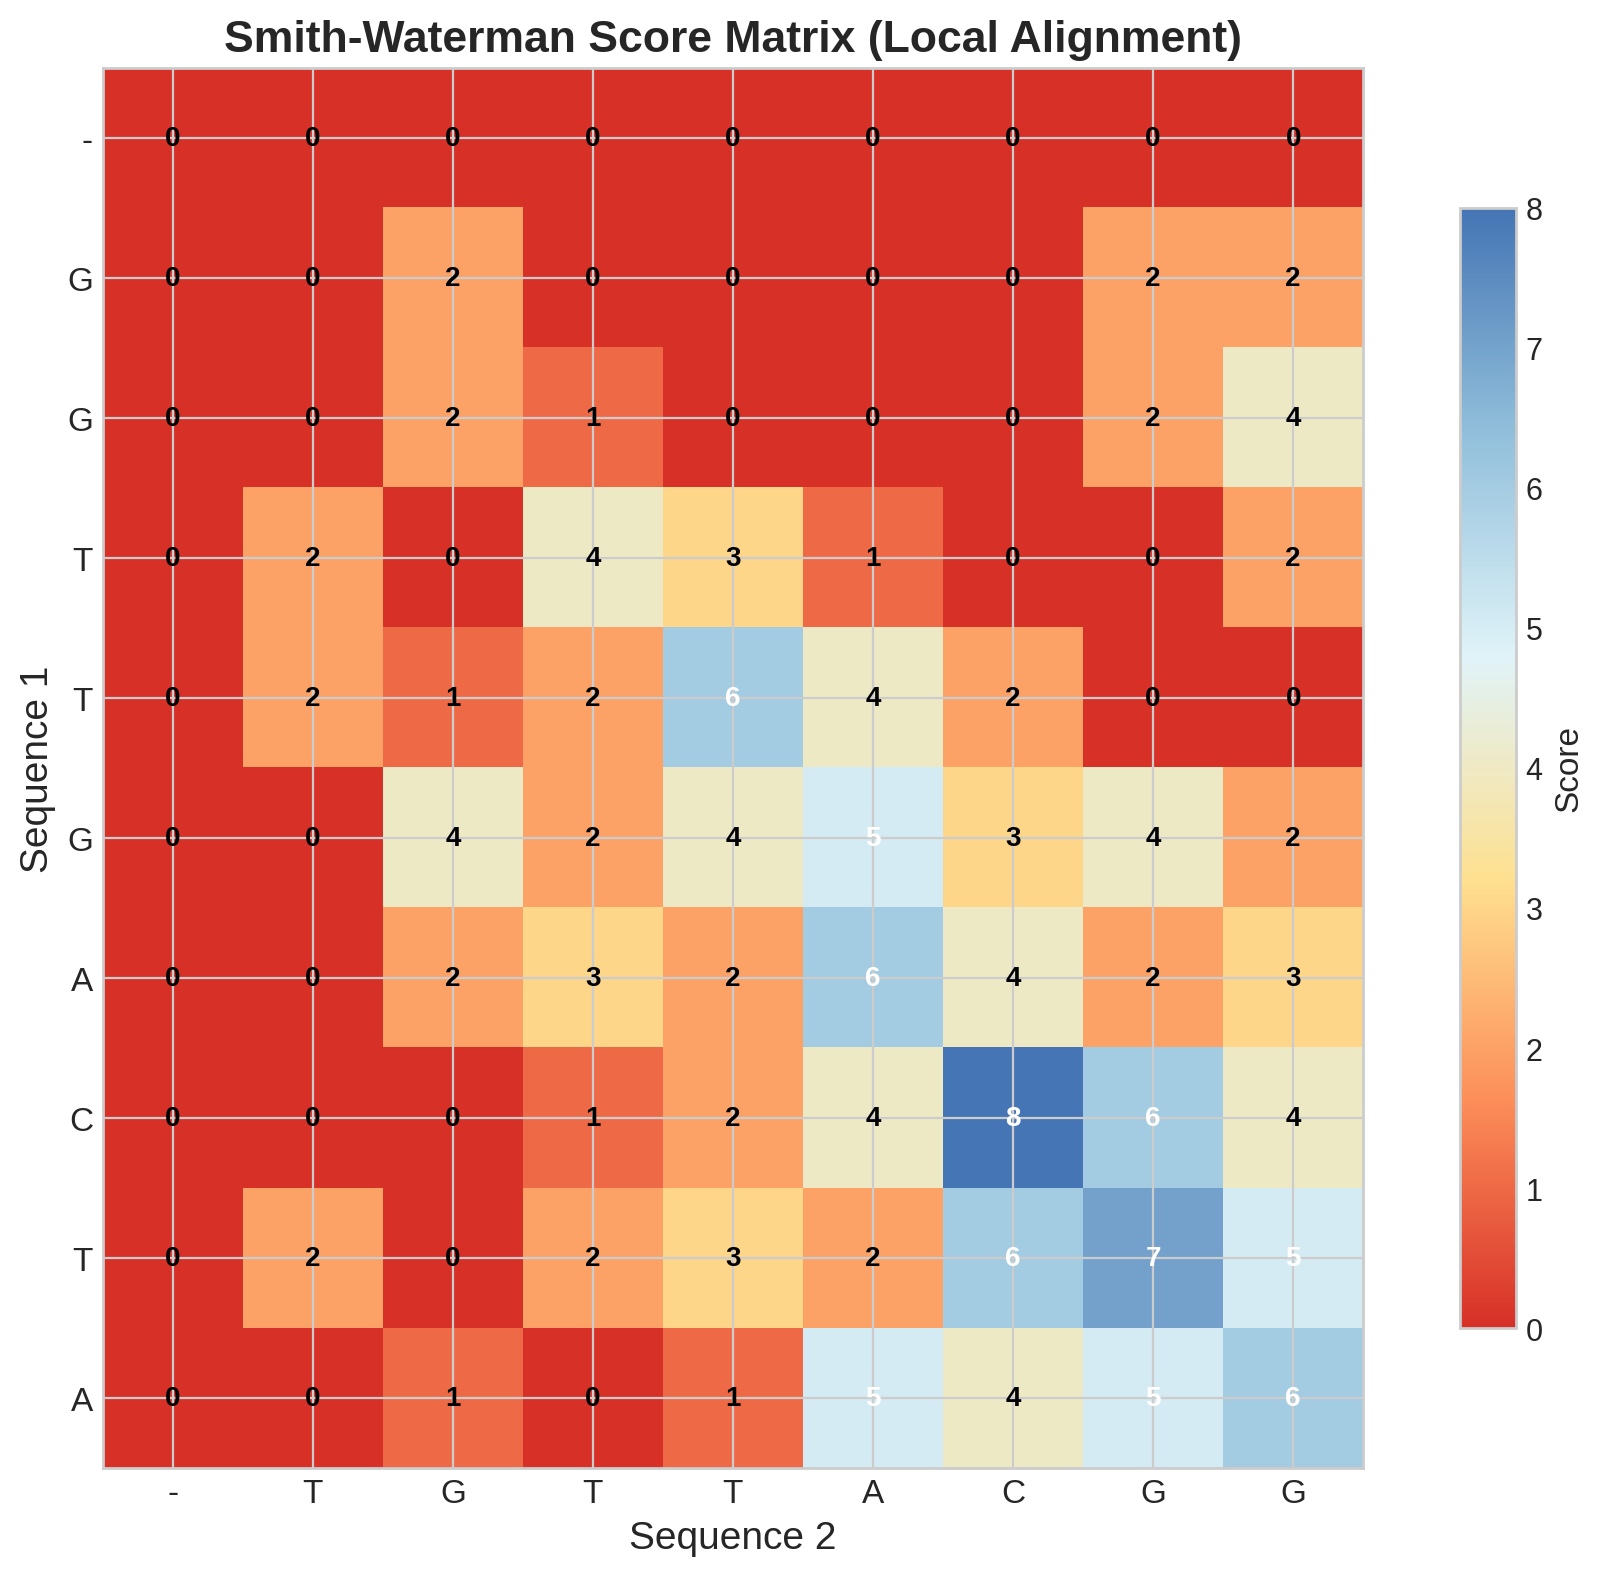

Plot saved: sequence_alignment_smith_waterman_matrix.png


In [6]:
# Visualize Smith-Waterman matrix
fig = visualize_alignment_matrix(seq1_local, seq2_local, sw_matrix,
                                  'Smith-Waterman Score Matrix (Local Alignment)')
plt.savefig('sequence_alignment_smith_waterman_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: sequence_alignment_smith_waterman_matrix.png")

## 5. Comparing Global vs Local Alignment

Let's see how the two algorithms differ on the same sequence pair.

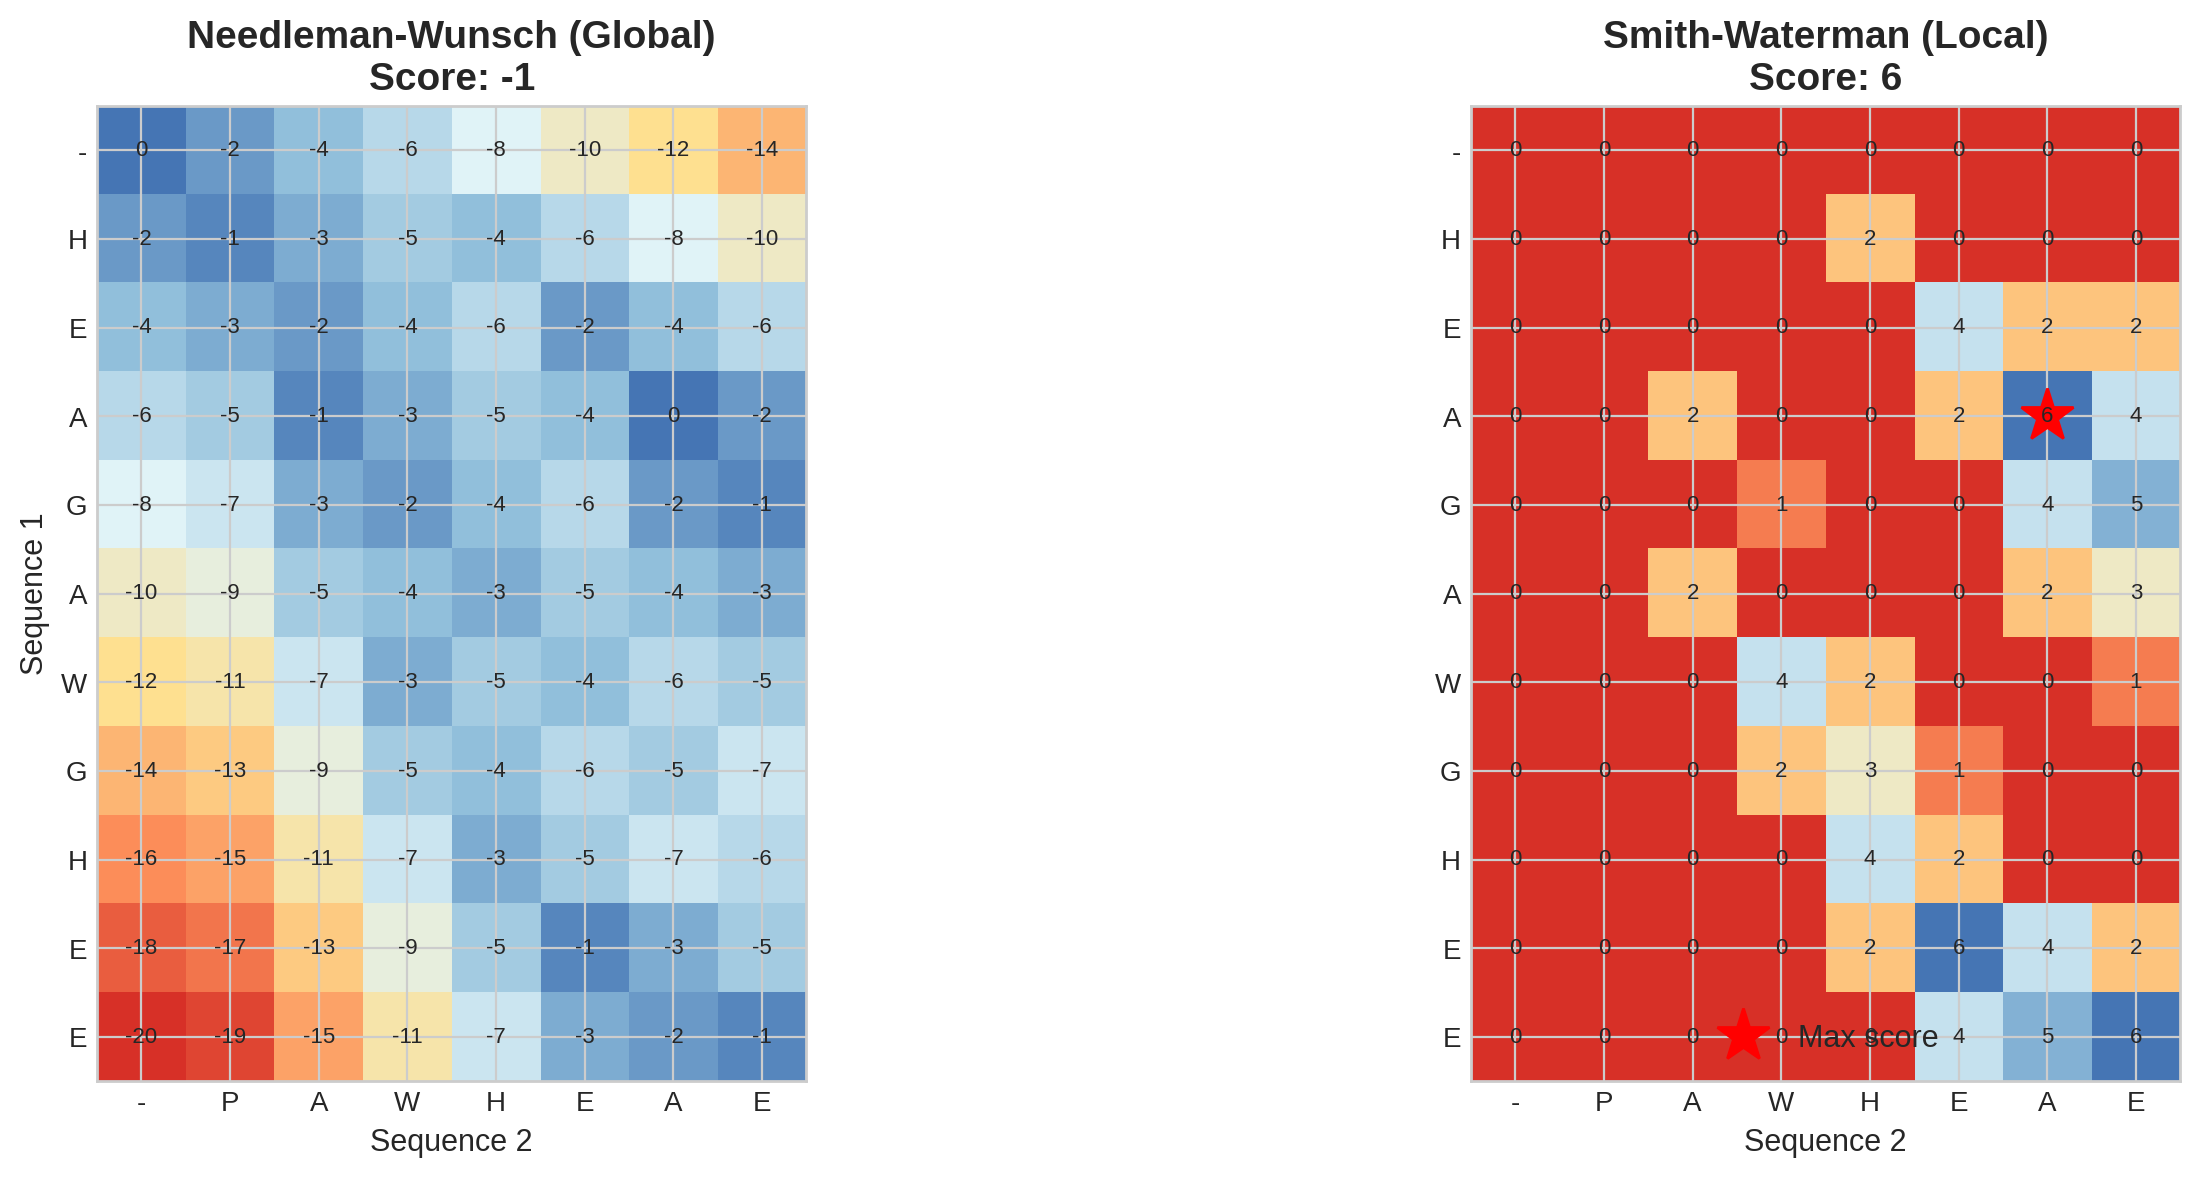

COMPARISON: Global vs Local Alignment

Sequence 1: HEAGAWGHEE
Sequence 2: PAWHEAE

GLOBAL (Needleman-Wunsch):
  HEAGAWGHE-E
      || || |
  ---PAW-HEAE
  Score: -1

LOCAL (Smith-Waterman):
  HEA
  |||
  HEA
  Score: 6

Plot saved: sequence_alignment_comparison.png


In [7]:
# Compare on same sequences
test_seq1 = "HEAGAWGHEE"
test_seq2 = "PAWHEAE"

# Global alignment
nw_a1, nw_a2, nw_matrix, nw_score = needleman_wunsch(test_seq1, test_seq2)

# Local alignment
sw_a1, sw_a2, sw_matrix, sw_score, sw_pos = smith_waterman(test_seq1, test_seq2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global alignment matrix
colors = ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4']
cmap = LinearSegmentedColormap.from_list('custom', colors)

ax1 = axes[0]
im1 = ax1.imshow(nw_matrix, cmap=cmap, aspect='equal')
ax1.set_xticks(range(len(test_seq2) + 1))
ax1.set_yticks(range(len(test_seq1) + 1))
ax1.set_xticklabels(['-'] + list(test_seq2), fontsize=10)
ax1.set_yticklabels(['-'] + list(test_seq1), fontsize=10)
for i in range(nw_matrix.shape[0]):
    for j in range(nw_matrix.shape[1]):
        ax1.text(j, i, int(nw_matrix[i,j]), ha='center', va='center', fontsize=8)
ax1.set_title(f'Needleman-Wunsch (Global)\nScore: {nw_score}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sequence 2')
ax1.set_ylabel('Sequence 1')

# Local alignment matrix
ax2 = axes[1]
im2 = ax2.imshow(sw_matrix, cmap=cmap, aspect='equal')
ax2.set_xticks(range(len(test_seq2) + 1))
ax2.set_yticks(range(len(test_seq1) + 1))
ax2.set_xticklabels(['-'] + list(test_seq2), fontsize=10)
ax2.set_yticklabels(['-'] + list(test_seq1), fontsize=10)
for i in range(sw_matrix.shape[0]):
    for j in range(sw_matrix.shape[1]):
        ax2.text(j, i, int(sw_matrix[i,j]), ha='center', va='center', fontsize=8)
ax2.plot(sw_pos[1], sw_pos[0], 'r*', markersize=20, label='Max score')
ax2.set_title(f'Smith-Waterman (Local)\nScore: {sw_score}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sequence 2')
ax2.legend()

plt.tight_layout()
plt.savefig('sequence_alignment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("="*60)
print("COMPARISON: Global vs Local Alignment")
print("="*60)
print(f"\nSequence 1: {test_seq1}")
print(f"Sequence 2: {test_seq2}")
print()
print("GLOBAL (Needleman-Wunsch):")
print(f"  {nw_a1}")
print(f"  {''.join(['|' if a==b and a!='-' else ' ' for a,b in zip(nw_a1, nw_a2)])}")
print(f"  {nw_a2}")
print(f"  Score: {nw_score}")
print()
print("LOCAL (Smith-Waterman):")
print(f"  {sw_a1}")
print(f"  {''.join(['|' if a==b and a!='-' else ' ' for a,b in zip(sw_a1, sw_a2)])}")
print(f"  {sw_a2}")
print(f"  Score: {sw_score}")

print("\nPlot saved: sequence_alignment_comparison.png")

## 6. Real DNA Sequence Example

Let's align actual DNA sequences to find conserved regions.

In [8]:
# Two related DNA sequences (simulating homologous genes)
dna1 = "ATGCGATCGATCGATCGTAGCTAGCTAGCTAG"
dna2 = "ATGCGATCGATCGATCGTAGCTAGCTAGCTAG"  # Identical for reference

# Introduce mutations (simulating evolution)
dna2_mutated = "ATGCGTTCGATCGAACGTAGCTAGATAGATAG"
#                     ^       ^           ^  ^^
#                    mutations shown with ^

# Align original vs mutated
aligned_dna1, aligned_dna2, _, dna_score = needleman_wunsch(
    dna1, dna2_mutated, match=1, mismatch=-1, gap=-2
)

# Calculate identity
matches = sum(1 for a, b in zip(aligned_dna1, aligned_dna2) if a == b and a != '-')
identity = matches / len(aligned_dna1) * 100

print("DNA Sequence Alignment")
print("="*60)
print(f"Original:  {dna1}")
print(f"Mutated:   {dna2_mutated}")
print()
print("Alignment:")

# Print in blocks of 50
block_size = 50
for i in range(0, len(aligned_dna1), block_size):
    block1 = aligned_dna1[i:i+block_size]
    block2 = aligned_dna2[i:i+block_size]
    match_line = ''.join(['|' if a==b else '*' if a!='-' and b!='-' else ' ' 
                          for a,b in zip(block1, block2)])
    print(f"  Seq1: {block1}")
    print(f"        {match_line}")
    print(f"  Seq2: {block2}")
    print()

print(f"Alignment Score: {dna_score}")
print(f"Sequence Identity: {identity:.1f}%")
print(f"Matches: {matches}/{len(aligned_dna1)}")

DNA Sequence Alignment
Original:  ATGCGATCGATCGATCGTAGCTAGCTAGCTAG
Mutated:   ATGCGTTCGATCGAACGTAGCTAGATAGATAG

Alignment:
  Seq1: ATGCGATCGATCGATCGTAGCTAGCTAGCTAG
        |||||*||||||||*|||||||||*|||*|||
  Seq2: ATGCGTTCGATCGAACGTAGCTAGATAGATAG

Alignment Score: 24
Sequence Identity: 87.5%
Matches: 28/32


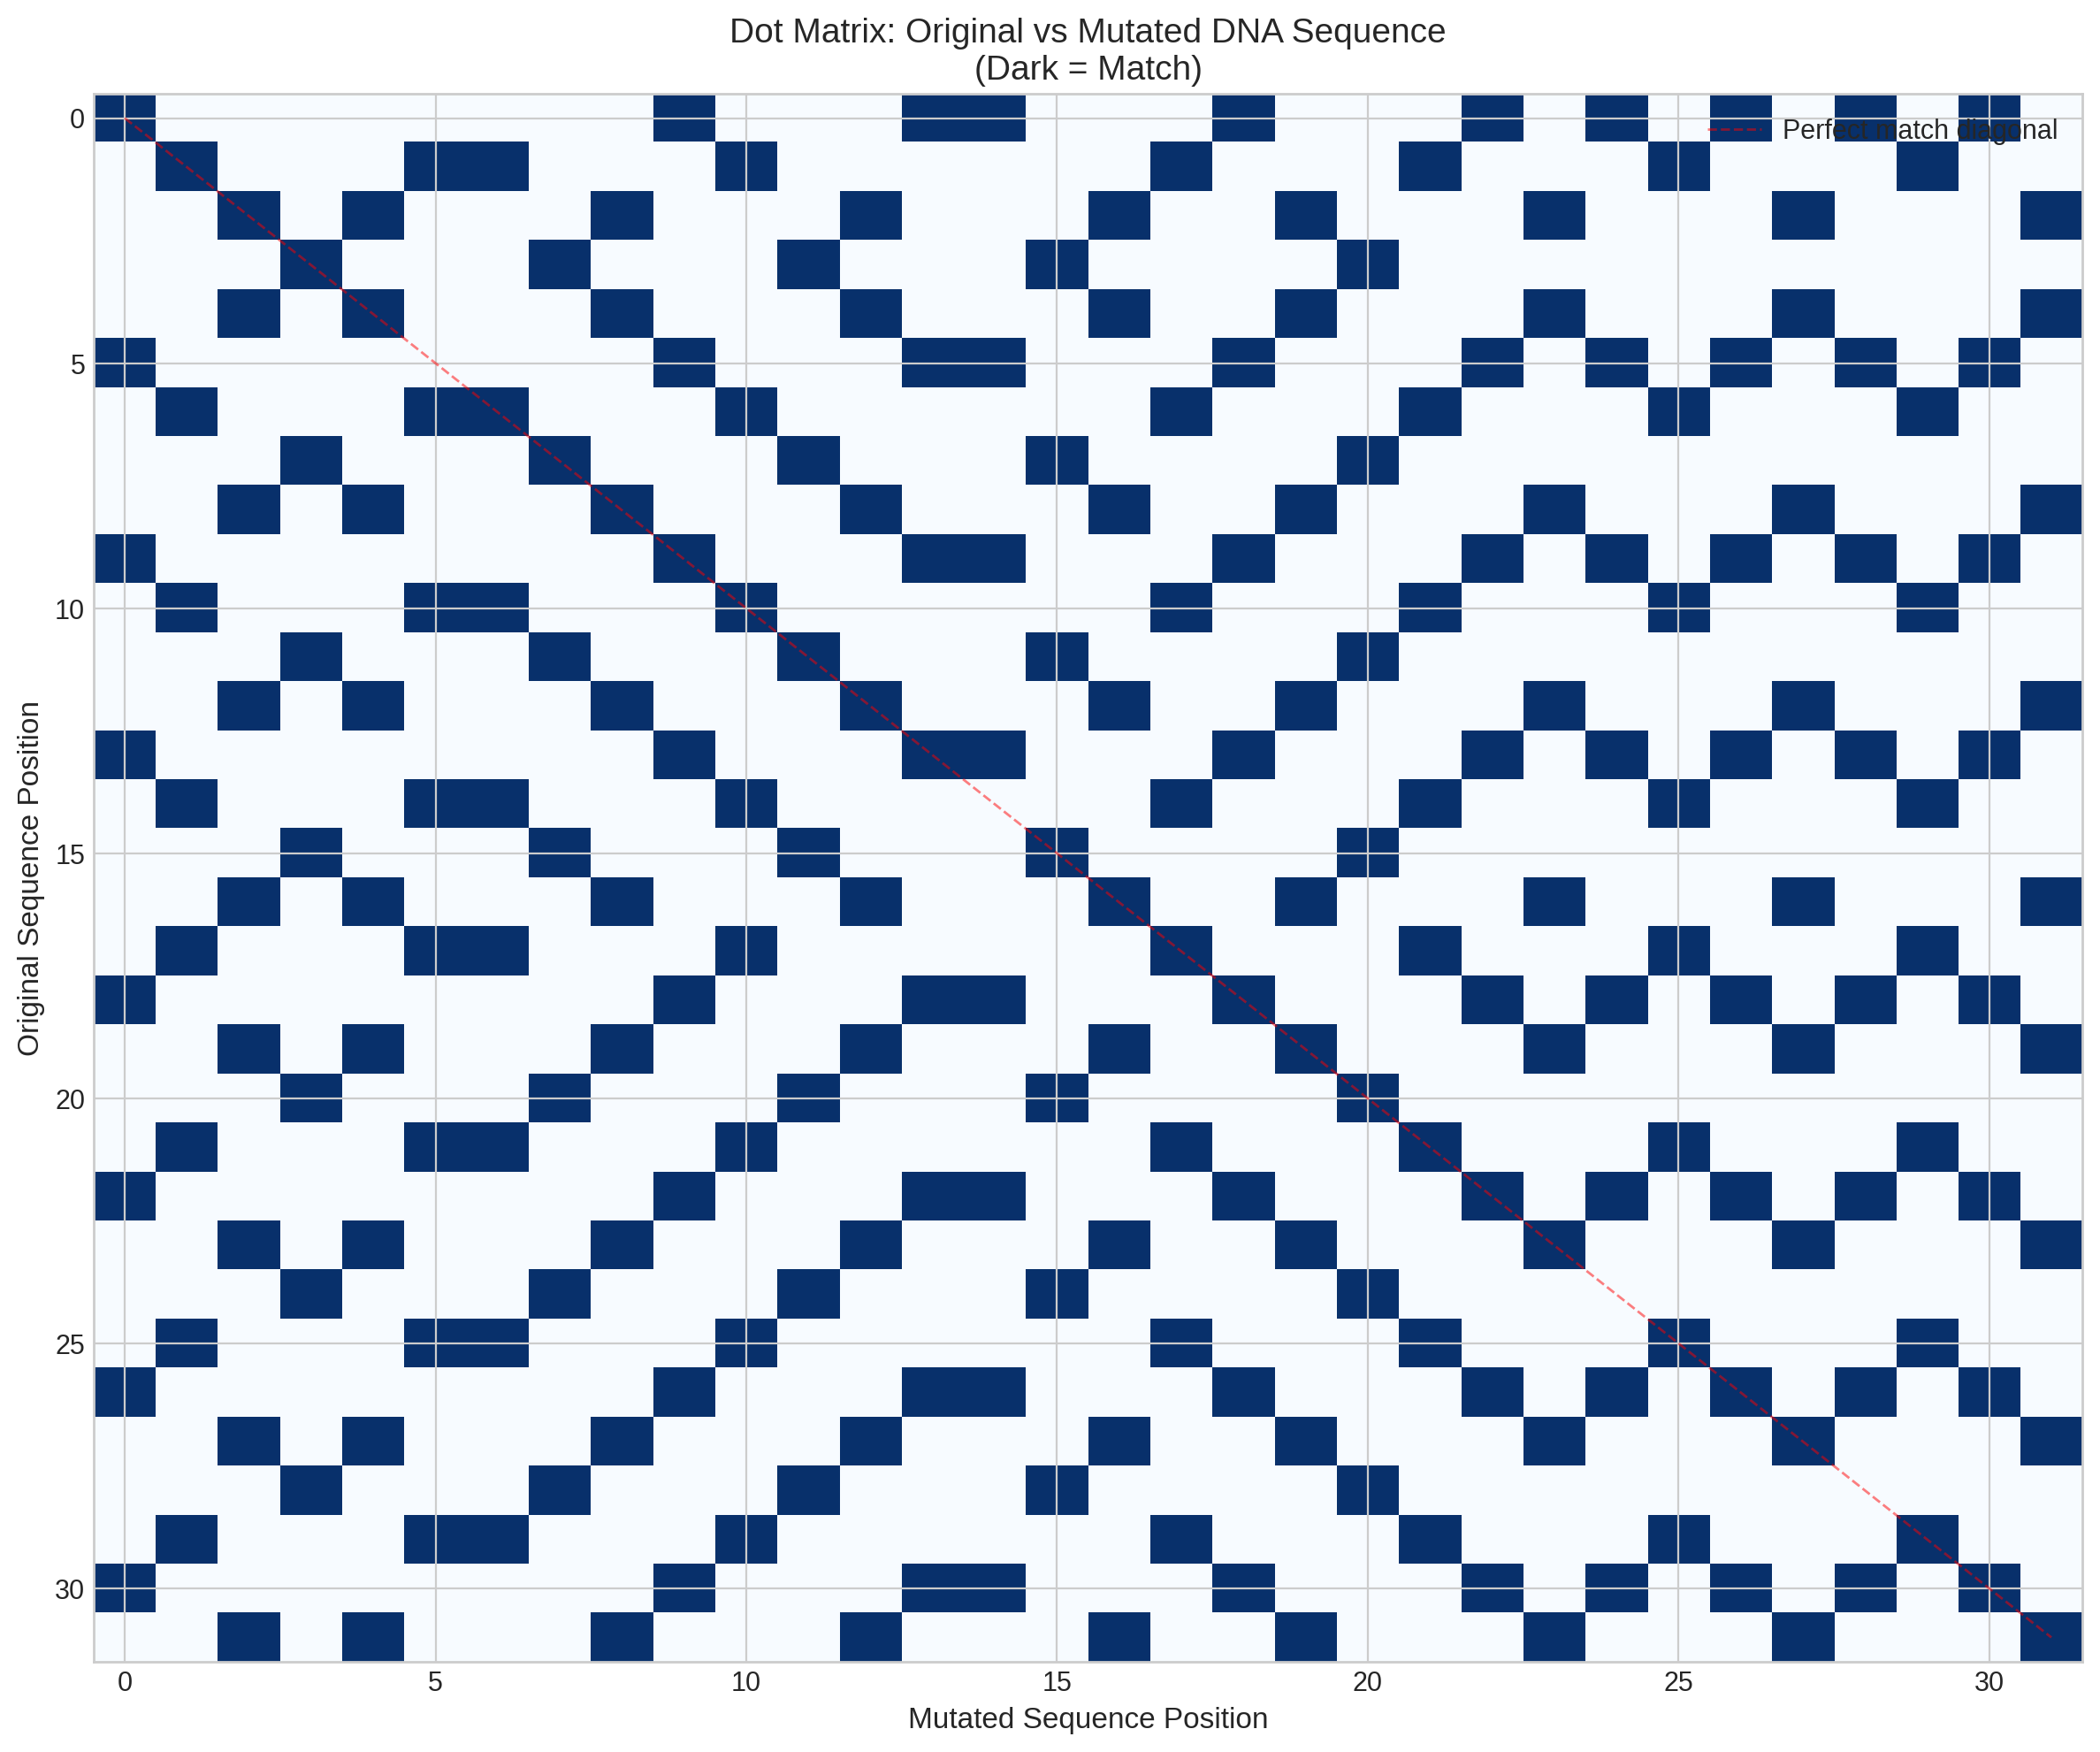

Plot saved: sequence_alignment_dot_matrix.png


In [9]:
# Visualize alignment as a dot matrix
def create_dot_matrix(seq1, seq2):
    """Create a dot matrix showing exact matches."""
    m, n = len(seq1), len(seq2)
    matrix = np.zeros((m, n))
    
    for i in range(m):
        for j in range(n):
            if seq1[i] == seq2[j]:
                matrix[i, j] = 1
    
    return matrix

# Create dot matrix
dot_matrix = create_dot_matrix(dna1, dna2_mutated)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot
ax.imshow(dot_matrix, cmap='Blues', aspect='auto', interpolation='nearest')

# Add diagonal line for perfect match reference
min_len = min(len(dna1), len(dna2_mutated))
ax.plot(range(min_len), range(min_len), 'r--', linewidth=1, alpha=0.5, label='Perfect match diagonal')

ax.set_xlabel('Mutated Sequence Position', fontsize=12)
ax.set_ylabel('Original Sequence Position', fontsize=12)
ax.set_title('Dot Matrix: Original vs Mutated DNA Sequence\n(Dark = Match)', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('sequence_alignment_dot_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: sequence_alignment_dot_matrix.png")

## 7. Algorithm Complexity and Applications

### Computational Complexity

| Aspect | Needleman-Wunsch | Smith-Waterman |
|--------|------------------|----------------|
| Time | O(mn) | O(mn) |
| Space | O(mn) | O(mn) |
| Optimal | Yes | Yes |

### Real-World Applications

1. **BLAST** (Basic Local Alignment Search Tool): Uses heuristics based on Smith-Waterman
2. **Gene finding**: Aligning genomic DNA to mRNA
3. **Protein structure prediction**: Finding similar proteins with known structures
4. **Evolutionary analysis**: Building phylogenetic trees
5. **Drug discovery**: Finding binding sites

In [10]:
# Summary statistics
print("Sequence Alignment Summary")
print("="*50)
print()
print("Algorithms Implemented:")
print("  1. Needleman-Wunsch (Global Alignment)")
print("  2. Smith-Waterman (Local Alignment)")
print()
print("Key Parameters:")
print(f"  Match Score:      +{MATCH}")
print(f"  Mismatch Penalty: {MISMATCH}")
print(f"  Gap Penalty:      {GAP}")
print()
print("Use Cases:")
print("  Global: When sequences are similar length and")
print("          you want to align them end-to-end")
print("  Local:  When looking for conserved regions")
print("          within longer, dissimilar sequences")
print()
print("Complexity: O(mn) time and space")
print("            where m, n are sequence lengths")

Sequence Alignment Summary

Algorithms Implemented:
  1. Needleman-Wunsch (Global Alignment)
  2. Smith-Waterman (Local Alignment)

Key Parameters:
  Match Score:      +2
  Mismatch Penalty: -1
  Gap Penalty:      -2

Use Cases:
  Global: When sequences are similar length and
          you want to align them end-to-end
  Local:  When looking for conserved regions
          within longer, dissimilar sequences

Complexity: O(mn) time and space
            where m, n are sequence lengths
